# Week 4 Day 2: Feature Engineering, Cross-Validation & Model Comparison
### Goal: 
Create and justify features

rebuild pipeline with new features 

Comparing more models using cross-validation (LogisticRegression
RandomForestClassifier
GradientBoosting (HistGradientBoosting / XGBoost / LightGBM))

Training two supervised models: logistic regression and decision trees

Running Statistical Tests b/w top 2 models

### Dataset (same as before)

We are using the Adult Census Income Dataset.

Some stuff we did for day 1:

* 0 = <=50K
* 1 = >50K
## The Workflow I'm going with (including basic imports and loads + cleaning)
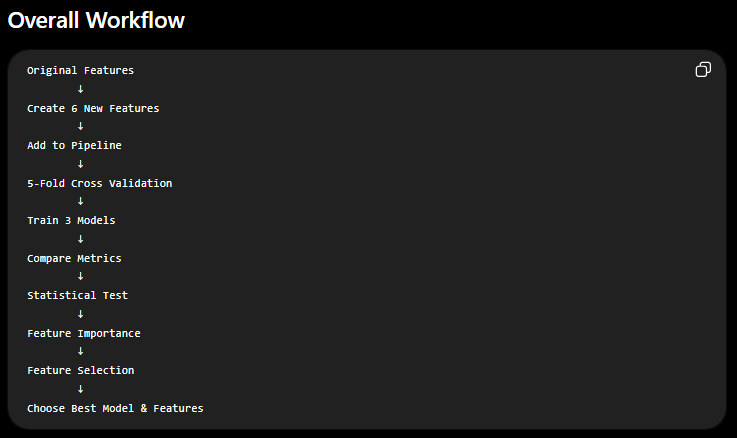
## Imports and Loading


In [1]:
%pip install xgboost
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#from day 2
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

#for day 3 task 5 and 1
from sklearn.feature_selection import SelectKBest, mutual_info_classif

#more for the pipeline 
from sklearn.preprocessing import FunctionTransformer

#for models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#for crossvalidation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

#for task 4 stats
from scipy.stats import ttest_rel
#for task 5
import time

import warnings
warnings.filterwarnings('ignore')

In [3]:
adult = fetch_openml(
    name="adult",
    version=2,              #apparently the second version doesnt have any ? so thats why i wasnt able to "clean" that
    as_frame=True
)

df = adult.frame.copy()
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Basic Cleaning

In [4]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

In [5]:
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})   #mapping it just like day1

In [6]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [7]:
df.shape

(48842, 15)

### Splitting from Day 1

In [8]:
X = df.drop("income", axis=1)
y = df["income"]

In [9]:
# Dropping columns that we wont need 
X = X.drop(columns=["education", "fnlwgt"])

In [10]:
# splitting 80-20 (cant use it rn) (DONT TOUCH THIS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y) 

In [11]:
#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=42)

In [12]:
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)

Training: (35165, 12)
Development: (3908, 12)
Test: (9769, 12)


In [13]:
print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

income
0    0.760728
1    0.239272
Name: proportion, dtype: float64
income
0    0.760747
1    0.239253
Name: proportion, dtype: float64
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


## Previous Pipeline

## Task 1: Creating & Justifying Engineered Features
Time to add new features

In [14]:
# copying the training data first 
X_eng = X.copy()


### Feature 1: Age bucket (age range)
**Justification:** Its easier since income usually changes with age and career stage. People in similar age ranges often earn similar incomes.

In [15]:
X_eng["age_bucket"] = pd.cut(
    X_eng["age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)


### Feature 2: Hours-per-week Bucket
**Justification:** Working more hours may be related to higher income. It usually is though

In [16]:
X_eng["hours_bucket"] = pd.cut(
    X_eng["hours-per-week"],
    bins=[0, 30, 40, 50, 100],
    labels=["Part-time", "Full-time", "Overtime", "Heavy Overtime"]
)

### Feature 3: Capital Gain Flag
**Justification:** Even a small capital gain can indicate higher income so this will be good instead of having to identify ranges

In [17]:
X_eng["capital_gain_flag"] = (
    X_eng["capital-gain"] > 0
).astype(int)

### Feature 4: Log Capital Gain 
**Justification:** This will get rid of the skewness we saw earlier in the previous days

In [18]:
X_eng["log_capital_gain"] = np.log1p(
    X_eng["capital-gain"]
)

### Feature 5: Higher Education Flag
**Justification:** College education is often associated with higher salaries so lets go with this

In [19]:
X_eng["higher_education"] = (
    X_eng["education-num"] >= 13
).astype(int)

### Feature 6: Interaction of Education × Hours Worked
**Justification:** Since people with higher education and more hours worked most probably are richer :D (well maybe not more hours worked, overworking is not good)

In [20]:
X_eng["edu_hours"] = (
    X_eng["education-num"]
    * X_eng["hours-per-week"]
)

In [21]:
X_eng

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,age_bucket,hours_bucket,capital_gain_flag,log_capital_gain,higher_education,edu_hours
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,18-25,Full-time,0,0.000000,0,280
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,36-45,Overtime,0,0.000000,0,450
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,26-35,Full-time,0,0.000000,0,480
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,36-45,Full-time,1,8.947546,0,400
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,18-25,Part-time,0,0.000000,0,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,26-35,Full-time,0,0.000000,0,456
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,36-45,Full-time,0,0.000000,0,360
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,56+,Full-time,0,0.000000,0,360
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,18-25,Part-time,0,0.000000,0,180


### Feature Dictionary

In [22]:
feature_dictionary = pd.DataFrame({
    "Feature":[
        "age_bucket",
        "hours_bucket",
        "capital_gain_flag",
        "log_capital_gain",
        "higher_education",
        "edu_hours"
    ],

    "Type":[
        "Categorical",
        "Categorical",
        "Binary",
        "Numeric",
        "Binary",
        "Numeric"
    ],

    "Creation Rule":[
        "Age grouped into ranges",
        "Hours grouped into ranges",
        "capital-gain > 0",
        "log1p(capital-gain)",
        "education-num >= 13",
        "education-num × hours-per-week"
    ],

    "Why it may help":[
        "Captures career stages",
        "Captures work intensity",
        "Identifies investment income",
        "Reduces skew",
        "Identifies highly educated people",
        "Captures interaction between education and workload"
    ]
})

feature_dictionary

,Feature,Type,Creation Rule,Why it may help
0,age_bucket,Categorical,Age grouped into ranges,Captures career stages
1,hours_bucket,Categorical,Hours grouped into ranges,Captures work intensity
2,capital_gain_flag,Binary,capital-gain > 0,Identifies investment income
3,log_capital_gain,Numeric,log1p(capital-gain),Reduces skew
4,higher_education,Binary,education-num >= 13,Identifies highly educated people
5,edu_hours,Numeric,education-num × hours-per-week,Captures interaction between education and wor...


### Checking Predictive Signal (Mutual Information)
Apparently the easiest method is Mutual Information. Lets get into that
**MI:** measures how much information one variable shares with another. In simple terms, it quantifies how much knowing the value of **Feature X** reduces our uncertainty about the **Target Y**.

In [23]:
# encoding categorical features first

X_mi = X_eng.copy()

for col in ["age_bucket","hours_bucket"]:
    X_mi[col] = X_mi[col].astype("category").cat.codes

In [24]:
## Computing Mutual Information
mi = mutual_info_classif(
    X_mi[
        [
            "age_bucket",
            "hours_bucket",
            "capital_gain_flag",
            "log_capital_gain",
            "higher_education",
            "edu_hours"
        ]
    ],
    y,
    random_state=42
)

pd.DataFrame({
    "Feature":[
        "age_bucket",
        "hours_bucket",
        "capital_gain_flag",
        "log_capital_gain",
        "higher_education",
        "edu_hours"
    ],
    "Mutual Information":mi
}).sort_values(
    "Mutual Information",
    ascending=False
)

,Feature,Mutual Information
5,edu_hours,0.081803
3,log_capital_gain,0.079013
0,age_bucket,0.059296
4,higher_education,0.051347
1,hours_bucket,0.041772
2,capital_gain_flag,0.026443


**Observation**: The Mutual Information scores show that edu_hours and log_capital_gain are the most useful engineered features, meaning they have the strongest relationship with income. Age buckets and the higher education flag also provide useful information, while hours buckets have a smaller effect. The capital gain flag has the lowest score, suggesting that using the actual log-transformed capital gain is more informative than just checking whether it is greater than zero.


## Task 2: Rebuilding Pipeline with Engineered Features

Will have to make a function to be able to use FunctionTransformer. Welp lets just copy and paste the feature engineering code from above and add it here

In [25]:
def create_features(X):
    X = X.copy()

    # Age bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[17, 25, 35, 45, 55, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56+"]
    )

    # Hours bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 30, 40, 50, 100],
        labels=["Part-time", "Full-time", "Overtime", "Heavy Overtime"]
    )

    # Capital gain flag
    X["capital_gain_flag"] = (X["capital-gain"] > 0).astype(int)

    # Log capital gain
    X["log_capital_gain"] = np.log1p(X["capital-gain"])

    # Higher education flag
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # Interaction feature
    X["edu_hours"] = X["education-num"] * X["hours-per-week"]

    return X

In [26]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [27]:
#updating feat list
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "higher_education",
    "log_capital_gain",
    "edu_hours"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

### Preprocessing

In [28]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [29]:
full_pipeline = Pipeline([
    ("feature_eng", feature_transformer),
    ("preprocess", preprocessor),
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002118211E140>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to p

## Task 3: Cross-Validated Model Comparison
### Models
#### 1. Logistic Regression

In [30]:
log_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        solver="liblinear"
    ))
])

#### 2. Random Forest Classifier

In [31]:
rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

#### 3. Gradient Boosting
Going to try all 3 and pick the best one at the end
#### A: HistGradientBoostingClassifier

In [32]:
gb_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=42
    ))
])

#### B: XGBoost

In [33]:
xgb_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss"
    ))
])

#### C: LightGBM

In [34]:
lgbm_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1
    ))
])

### Metrics

In [35]:
scoring = {

    "precision":"precision",

    "roc_auc":"roc_auc",

    "f1":"f1"

}

### Cross-Validation (CV)
Okie lets get into this now

In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [37]:
models = {

    "Logistic Regression":log_pipeline,
    "Random Forest":rf_pipeline,
    #gonna pick the best one out of these three
    "Gradient Boosting":gb_pipeline,
    "XGBoost" : xgb_pipeline,
    "LightGBM" : lgbm_pipeline
}

In [38]:
results = []

for name,model in models.items():
#finally on cross validation
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model":name,
        "Precision":
        f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}",
        "ROC AUC":
        f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        "F1":
        f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}"
    })

cv_results = pd.DataFrame(results)

cv_results

[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003801 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 92
[LightGBM] [Info] [bin

,Model,Precision,ROC AUC,F1
0,Logistic Regression,0.747 ± 0.008,0.912 ± 0.002,0.672 ± 0.005
1,Random Forest,0.710 ± 0.006,0.895 ± 0.003,0.664 ± 0.008
2,Gradient Boosting,0.779 ± 0.007,0.928 ± 0.002,0.709 ± 0.006
3,XGBoost,0.786 ± 0.010,0.928 ± 0.002,0.706 ± 0.007
4,LightGBM,0.782 ± 0.008,0.929 ± 0.002,0.712 ± 0.006


**Final Boosting Model:** Overall, LightGBM performed the best across the different evaluation metrics. Although XGBoost achieved the highest Precision (0.786), LightGBM's Precision (0.782) was almost the same while also giving the highest ROC AUC (0.929) and F1-score (0.712).
I will be going with **LightGBM**.

### Boxplots of Fold Scores Across the 3 Metrics

In [39]:
#getting scores to plot boxplots
log_scores = cross_validate(log_pipeline, X, y, cv=cv, scoring=scoring)
rf_scores = cross_validate(rf_pipeline, X, y, cv=cv, scoring=scoring)
lgbm_scores = cross_validate(lgbm_pipeline, X, y, cv=cv, scoring=scoring)

log_scores

[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 92
[LightGBM] [Info] [bin

{'fit_time': array([0.52383614, 0.56897593, 0.51878548, 0.57093573, 0.55395031]),
 'score_time': array([0.06440353, 0.06371212, 0.06282377, 0.06138706, 0.06213188]),
 'test_precision': array([0.7408377 , 0.75454074, 0.73435897, 0.75198728, 0.75078864]),
 'test_roc_auc': array([0.9100428 , 0.91413321, 0.91024379, 0.91533338, 0.91229259]),
 'test_f1': array([0.66619586, 0.68182884, 0.66806625, 0.671875  , 0.67374381])}

### Boxplot for Precision (main metric), ROC AUC and F1 (all in one

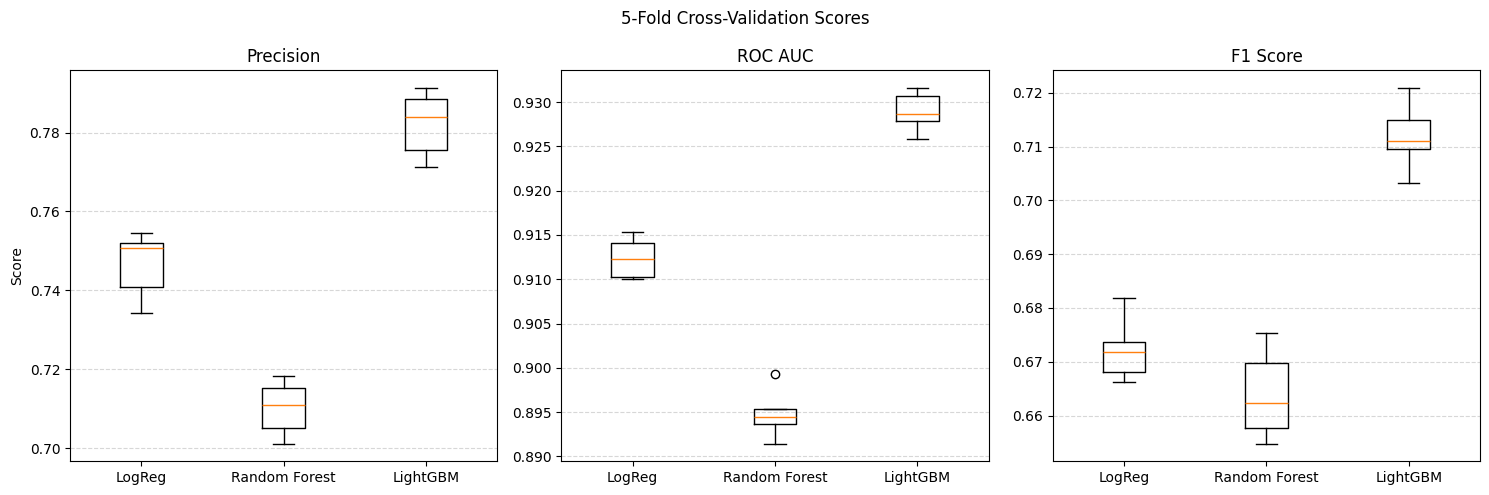

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Precision
axes[0].boxplot([
    log_scores["test_precision"],
    rf_scores["test_precision"],
    lgbm_scores["test_precision"]
])
axes[0].set_title("Precision")
axes[0].set_xticklabels(["LogReg", "Random Forest", "LightGBM"])
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# ROC AUC
axes[1].boxplot([
    log_scores["test_roc_auc"],
    rf_scores["test_roc_auc"],
    lgbm_scores["test_roc_auc"]
])
axes[1].set_title("ROC AUC")
axes[1].set_xticklabels(["LogReg", "Random Forest", "LightGBM"])
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# F1 Score
axes[2].boxplot([
    log_scores["test_f1"],
    rf_scores["test_f1"],
    lgbm_scores["test_f1"]
])
axes[2].set_title("F1 Score")
axes[2].set_xticklabels(["LogReg", "Random Forest", "LightGBM"])
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("5-Fold Cross-Validation Scores")
plt.tight_layout()
plt.show()

**Primary metric (Precision) mean ± std across folds** is what decides the ranking here, since thats been our main one since Day 1

**Observation:** The boxplots show that LightGBM performs the best across all three metrics. It has the highest median Precision, ROC AUC, and F1 scores, while also having a small spread across the five folds, which means its performance is consistent. Logistic Regression comes in second with stable results, whereas Random Forest has the lowest scores overall. Based on these results, **LightGBM** is the best model to continue with since it gives the strongest and most reliable performance, nice

## Task 4: Statistical Comparison & Feature Importance
### My Top 2 Models:
* Logistic Regression
* LightGBM

Since LightGBM and Logistic Regression are my top two models, ill compare their Precision scores

### Paired t-test

In [41]:
t_stat, p_value = ttest_rel(
    lgbm_scores["test_precision"],
    log_scores["test_precision"]
)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))


t-statistic: 17.762
p-value: 0.0001


**Interpretation:** The p-value is 0.0001 making it below 0.05, so the difference between LightGBM and Logistic Regression is statistically significant, noice we found a better model that is backed-up! This means LightGBM's higher Precision is unlikely to be due to chance, making it the better model :D

***LightGBM wins!***

### Feature Importances of LightGBM (Tree-Based Model)

In [43]:
#training 
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002118211E140>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [44]:
feature_names = (lgbm_pipeline.named_steps["preprocessor"].get_feature_names_out())

importances = (lgbm_pipeline.named_steps["classifier"].feature_importances_)

importance_df = (pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
)

importance_df.head(15)

,Feature,Importance
0,num__age,517
8,num__edu_hours,399
2,num__capital-gain,364
3,num__capital-loss,322
1,num__education-num,183
4,num__hours-per-week,166
19,cat__marital-status_Married-civ-spouse,69
27,cat__occupation_Exec-managerial,58
14,cat__workclass_Self-emp-not-inc,56
43,cat__relationship_Wife,46


Wait no i should probably do it for engineered features

In [45]:
engineered = [
    "num__capital_gain_flag",
    "num__higher_education",
    "num__log_capital_gain",
    "num__edu_hours",
    "cat__age_bucket",
    "cat__hours_bucket"
]

importance_df[
    importance_df["Feature"].str.contains(
        "|".join(engineered)
    )
]

,Feature,Importance
8,num__edu_hours,399
99,cat__hours_bucket_Overtime,29
95,cat__age_bucket_46-55,20
94,cat__age_bucket_36-45,17
97,cat__hours_bucket_Full-time,16
93,cat__age_bucket_26-35,10
6,num__higher_education,1
7,num__log_capital_gain,0
5,num__capital_gain_flag,0
92,cat__age_bucket_18-25,0


Okay good, education x hours bracket seems to have the most importance for LightGBM

### Coefficients of Logistic Regression

In [47]:
log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002118211E140>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [48]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_pipeline.named_steps["classifier"].coef_[0]
})

coef_df[
    coef_df["Feature"].str.contains(
        "|".join(engineered)
    )
].sort_values("Coefficient", ascending=False)

,Feature,Coefficient
7,num__log_capital_gain,6.096321
95,cat__age_bucket_46-55,0.377729
94,cat__age_bucket_36-45,0.219372
99,cat__hours_bucket_Overtime,0.180028
6,num__higher_education,0.048813
98,cat__hours_bucket_Heavy Overtime,0.032185
96,cat__age_bucket_56+,-0.042906
97,cat__hours_bucket_Full-time,-0.235702
8,num__edu_hours,-0.254006
93,cat__age_bucket_26-35,-0.313885


* **Top Positive Coefficient:** num__log_capital_gain = 6.096321
* **Top Negtive Coefficient:** num__capital_gain_flag = -5.70

#### Question: Which engineered features mattered most and does that make sense?
The engineered features were useful in both models. In **LightGBM**, **edu_hours** was the most important feature, followed by the age and hours buckets. In **Logistic Regression**, **log_capital_gain** had the strongest positive effect, while **num__capital_gain_flag, age 18–25 and part-time work** had the strongest negative effect.

Overall, these results make sense. Income is usually influenced by education, work experience, working hours, and investment income, so it's expected that these features have the biggest impact on the predictions

## Task 5: Feature Selection / Dimensionality Check
Ill go for SelectKBest for now

In [49]:
#adding it into the preprocessing pipeline
feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=30
)

In [50]:
# creating a new bgm pipeline for it (since we need the feature selector)
selected_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("selector", feature_selector),
    ("classifier", LGBMClassifier(random_state=42))
])

### Measuring Performance and Time

In [51]:
start = time.time()

selected_scores = cross_validate(
    selected_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)

elapsed = time.time() - start


[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 30
[LightGBM] [Info] [bin

In [52]:
print("Training time:", round(elapsed, 2), "seconds")
print("Precision:", selected_scores["test_precision"].mean())
print("ROC AUC:", selected_scores["test_roc_auc"].mean())
print("F1:", selected_scores["test_f1"].mean())


Training time: 79.97 seconds
Precision: 0.7818086443456054
ROC AUC: 0.9258383518204102
F1: 0.6943796704812316


In [53]:
comparison = pd.DataFrame({
    "Model": ["Original LightGBM", "Feature Selection"],
    "Precision": [
        lgbm_scores["test_precision"].mean(),
        selected_scores["test_precision"].mean()
    ],
    "ROC AUC": [
        lgbm_scores["test_roc_auc"].mean(),
        selected_scores["test_roc_auc"].mean()
    ],
    "F1": [
        lgbm_scores["test_f1"].mean(),
        selected_scores["test_f1"].mean()
    ],
    "Training Time (s)": [
        "-",
        round(elapsed, 2)
    ]
})

comparison

,Model,Precision,ROC AUC,F1,Training Time (s)
0,Original LightGBM,0.782150,0.928927,0.711923,-
1,Feature Selection,0.781809,0.925838,0.694380,79.97


**Interpretation:** Feature selection did not improve the model. Precision, ROC AUC, and F1 all decreased slightly, plus it took ~80 seconds.

Feature selection was supposed to make training faster XD
Upon looking into it, it became slower because SelectKBest itself has to compute mutual information before training, weird

Feature selection probably does nothing for LightGBM since accoridng to the internet, it already ignores unimportant features internally and it handles lots of features really well. Plus i guess its not that good for small datsets anyway

## Features to Keep

In [54]:
selected_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 727
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...002118211E140>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [55]:
feature_names = selected_pipeline.named_steps["preprocessor"].get_feature_names_out()

selected_mask = selected_pipeline.named_steps["selector"].get_support()

selected_features = feature_names[selected_mask]

print(selected_features)

['num__age' 'num__education-num' 'num__capital-gain' 'num__capital-loss'
 'num__hours-per-week' 'num__capital_gain_flag' 'num__higher_education'
 'num__log_capital_gain' 'num__edu_hours' 'cat__workclass_Private'
 'cat__workclass_Self-emp-inc' 'cat__marital-status_Divorced'
 'cat__marital-status_Married-civ-spouse'
 'cat__marital-status_Never-married' 'cat__occupation_Exec-managerial'
 'cat__occupation_Other-service' 'cat__occupation_Prof-specialty'
 'cat__relationship_Husband' 'cat__relationship_Not-in-family'
 'cat__relationship_Own-child' 'cat__relationship_Unmarried'
 'cat__relationship_Wife' 'cat__sex_Female' 'cat__sex_Male'
 'cat__age_bucket_18-25' 'cat__age_bucket_36-45' 'cat__age_bucket_46-55'
 'cat__hours_bucket_Full-time' 'cat__hours_bucket_Overtime'
 'cat__hours_bucket_Part-time']


**Observation**: SelectKBest selected 30 features, including all of the important engineered features such as edu_hours, log_capital_gain, higher_education, capital_gain_flag, age_bucket, and hours_bucket. However, using only these selected features slightly reduced Precision, ROC AUC, and F1 compared to using the full feature set. 

Because of that, I will keep the **full feature set** for tomorrow's hyperparameter tuning, as it gives the best overall performance while still including the engineered features that showed strong predictive value.